In [1]:
# Looking at the pepto images

In [1]:
%pylab widget

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import os
import numpy as np
import pandas as pd

# Define the root directory to start the search
root_dir = './'

# Initialize an empty list to store the data
data_list = []
data_names = []

# Loop through the directory tree
for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.npy'):
            file_path = os.path.join(subdir, file)
            # Load the .npy file
            data = np.load(file_path)
            # Append the data to the list
            data_list.append(data)
            data_names.append(file_path)

In [3]:
# sort the data names and the data list using the same order
data_list = [x for _, x in sorted(zip(data_names, data_list))]
data_names = sorted(data_names)
data_list = np.array(data_list)

In [9]:
data_names

['./S1728_PeptoBismol_20_30_76_100_114_120/Bin1.npy',
 './S1728_PeptoBismol_20_30_76_100_114_120/Bin2.npy',
 './S1728_PeptoBismol_20_30_76_100_114_120/Bin3.npy',
 './S1728_PeptoBismol_20_30_76_100_114_120/Bin4.npy',
 './S1728_PeptoBismol_20_30_76_100_114_120/Bin5.npy',
 './S1728_PeptoBismol_20_30_76_100_114_120/Bin6.npy',
 './S1728_PeptoBismol_20_30_76_100_114_120/BinAll.npy',
 './S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin1.npy',
 './S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin2.npy',
 './S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin3.npy',
 './S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin4.npy',
 './S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin5.npy',
 './S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin6.npy',
 './S1728_PeptoBismol_AirScan_20_30_76_100_114_120/BinAll.npy',
 './S1728_PeptoBismol_BiAtt_20_30_76_100_114_120/Bin1.npy',
 './S1728_PeptoBismol_BiAtt_20_30_76_100_114_120/Bin2.npy',
 './S1728_PeptoBismol_BiAtt_20_30_76_100_114_120/Bin3.npy',
 './

In [4]:
import mpl_interactions as pli

In [11]:
# plt.figure()
# pli.hyperslicer(data_list.squeeze()[:])
two_views = data_list.squeeze()[:7]
darks = data_list.squeeze()[7:14]
inverted = data_list.squeeze()[14:21]
flood = data_list.squeeze()[21:28]
bismuth_filtered = data_list.squeeze()[28:35]
water_filtered = data_list.squeeze()[35:42]
Original_test = data_list.squeeze()[42:49]

In [ ]:
# analysis of the first images

/tmp/ipykernel_6383/1848314594.py:64: RuntimeWarning: invalid value encountered in divide
  corrected_image /= (flood_field)
/tmp/ipykernel_6383/1848314594.py:64: RuntimeWarning: divide by zero encountered in divide
  corrected_image /= (flood_field)


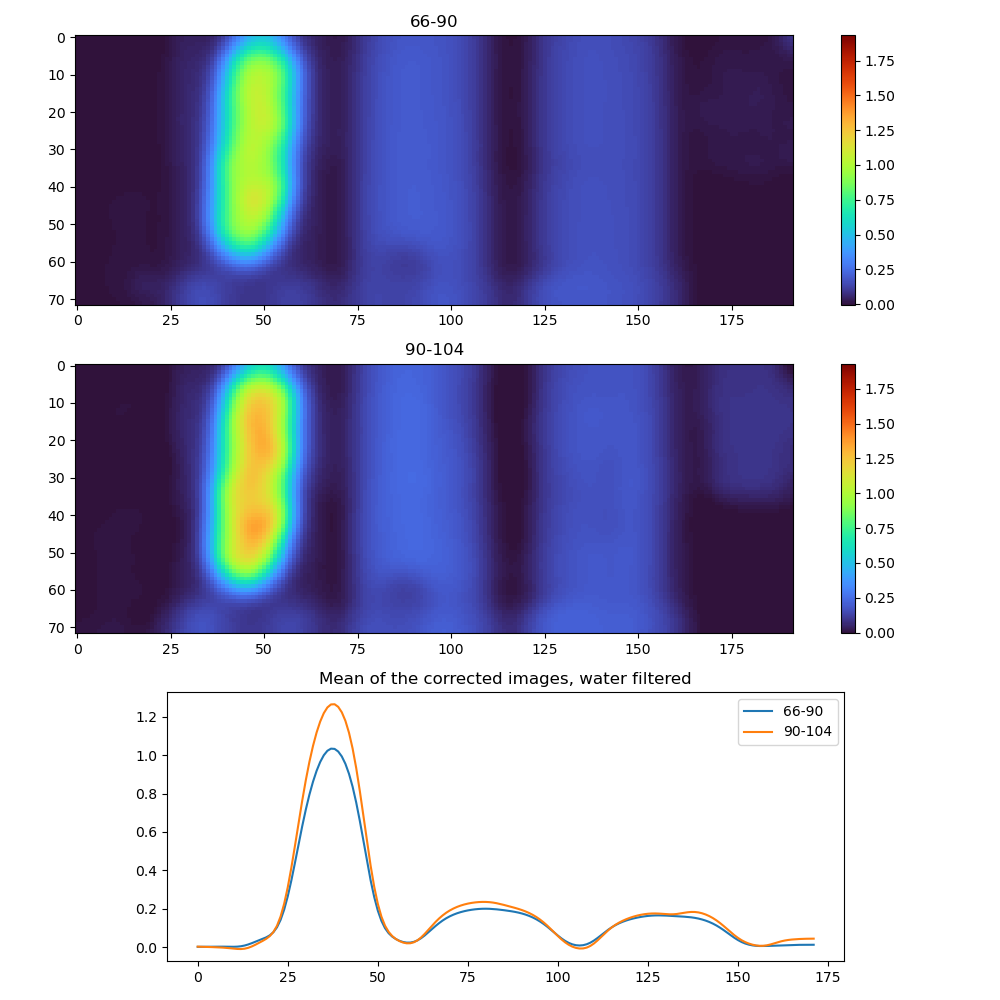

In [50]:
import numpy as np
import matplotlib.pyplot as plt


def detect_and_correct_pixels(image, lower_threshold, upper_threshold):
    """
    Detect and correct underresponding and overresponding pixels in an image.
    
    Parameters:
    - image: 2D numpy array representing the image.
    - lower_threshold: Threshold below which pixels are considered underresponding.
    - upper_threshold: Threshold above which pixels are considered overresponding.
    
    Returns:
    - corrected_image: Image with corrected pixels.
    """
    corrected_image = image.copy()
    
    # Detect underresponding and overresponding pixels
    underresponding_mask = image < lower_threshold
    overresponding_mask = image > upper_threshold
    
    # Get the indices of the pixels to be corrected
    underresponding_indices = np.argwhere(underresponding_mask)
    overresponding_indices = np.argwhere(overresponding_mask)
    
    # Function to calculate the mean of neighboring pixels
    def mean_of_neighbors(img, x, y):
        neighbors = []
        for i in range(max(0, x-1), min(img.shape[0], x+2)):
            for j in range(max(0, y-1), min(img.shape[1], y+2)):
                if (i, j) != (x, y):
                    neighbors.append(img[i, j])
        return np.mean(neighbors)
    
    # Correct underresponding pixels
    for x, y in underresponding_indices:
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    
    # Correct overresponding pixels
    for x, y in overresponding_indices:
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    
    return corrected_image

# Load your image data (replace with actual image loading code)
# For demonstration, we'll create synthetic images with some broken pixels
# Replace these with your actual data loading code
darks = data_list.squeeze()[7:13]
floods = data_list.squeeze()[21:27]
images = water_filtered

# Correct the images
corrected_images = []
for i in range(6):
    dark_field = darks[i]
    flood_field = floods[i]
    image = images[i].copy()
    flood_field -= dark_field
    
    flood_field = flood_field/np.mean(flood_field[:15, 20:-20]) * np.mean(image[:15, 20:-20])
    corrected_image = image.copy()
    corrected_image -= dark_field
    corrected_image /= (flood_field)
    
    corrected_image[corrected_image < 0.1] = 0.1
    corrected_image[corrected_image > 2] = 2
    corrected_image[np.isnan(corrected_image)] = 0.1
    # Load your image data (replace with actual image loading code)
    # For demonstration, we'll create a synthetic image with some broken pixels
    image = corrected_image.copy()

    # Calculate mean and standard deviation of the image
    mean = np.mean(image)
    std = np.std(image)

    # Define thresholds
    lower_threshold = mean - 1 * std
    upper_threshold = mean + 1 * std

    # Detect and correct broken pixels
    corrected_image = detect_and_correct_pixels(image, lower_threshold, upper_threshold)
    corrected_images.append(-np.log(corrected_image))

# gaussian filter the images
from scipy.ndimage import gaussian_filter
corrected_images = [gaussian_filter(image, 3) for image in corrected_images]

bins = [20 , 30, 76, 100, 114, 120]
bins = np.array(bins)  - 10
# make names out of the bins
names = []
for i in range(len(bins)-1):
    names.append(f'{bins[i]}-{bins[i+1]}')
# Plot the median of the corrected images
plt.figure(figsize=(10, 10))
for i in range(2,4):
    plt.subplot(3,1, i-1)
    plt.title(names[i])
    plt.imshow(np.rot90(corrected_images[i]), cmap='turbo', vmin=np.percentile(corrected_images[5], 1), vmax=np.percentile(corrected_images[5], 99))
    plt.colorbar()
# plt.show()

# Plot the median of the corrected images along a specific axis

# define a standard scaler
def standardize(image):
    return (image - np.mean(image))/np.std(image)

# Calculate the aspect ratio of the images
image_height, image_width = corrected_images[2].shape
aspect_ratio = image_height / image_width

# plt.figure()
plt.subplot(3,1,3)
for i in range(2,4):
    plt.plot(np.mean(corrected_images[i][10:-10,20:-20], axis=1), label=names[i])
# make sure the aspect is the same as the images plotted above
# Set the aspect ratio of the line plot to match the images

plt.gca().set_aspect(20*aspect_ratio, adjustable='box')
plt.legend()
plt.title('Mean of the corrected images, water filtered')
plt.tight_layout()
plt.show()

In [54]:
regions = [[25,50],[75,90],[120,140]]
region_names = ['Pill', 'Pepto', 'Water']

# make a bar chart of the mean of the regions

values = []
plt.figure()
for i in range(3):
    for j in range(5):
        plt.plot(i*5 + j, np.mean(corrected_images[j][regions[i][0]:regions[i][1],10:-10]),'*', label=f'{names[j]} {region_names[i]}')
        values.append(np.mean(corrected_images[j][regions[i][0]:regions[i][1],10:-10]))


plt.legend()
plt.title('Mean of the corrected images, in the different regions')
plt.show()

SyntaxError: invalid syntax (78417779.py, line 7)

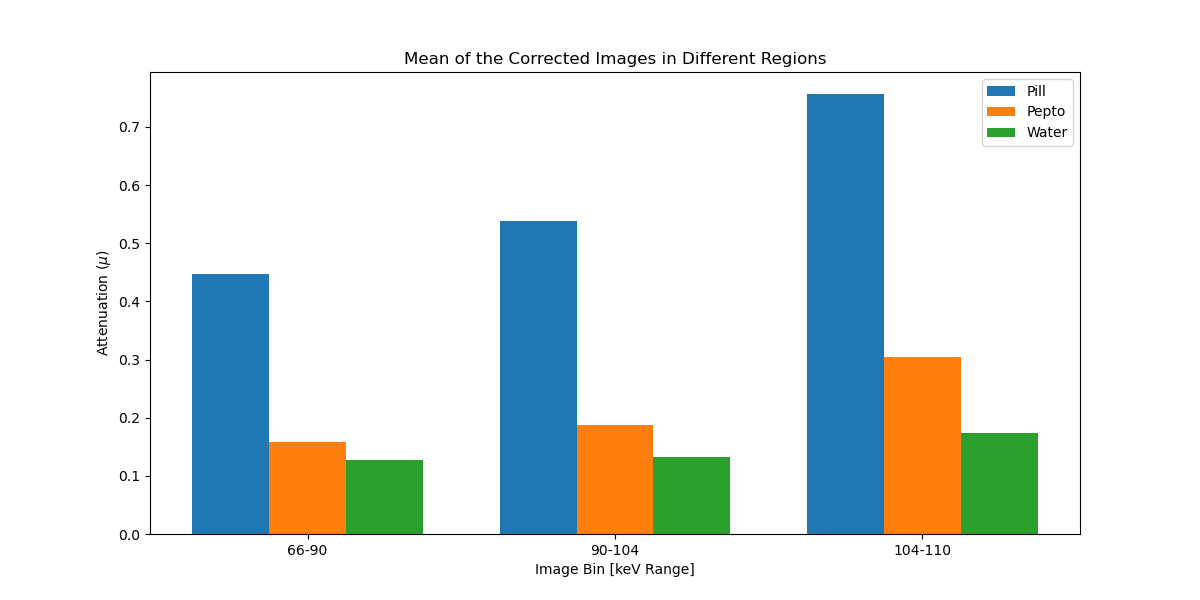

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming corrected_images and names are already defined
regions = [[25, 50], [75, 90], [120, 140]]
region_names = ['Pill', 'Pepto', 'Water']

# Calculate the mean values for the specified regions
values = []
for i in range(3):
    region_values = []
    for j in range(2,5):
        mean_value = np.mean(corrected_images[j][regions[i][0]:regions[i][1], 10:-10])
        region_values.append(mean_value)
    values.append(region_values)

# Convert the values list to a numpy array for easier manipulation
values = np.array(values)

# Create a bar chart
x = np.arange(2,5)  # There are 5 images in each region
width = 0.25  # Width of the bars

plt.figure(figsize=(12, 6))

for i in range(3):
    plt.bar(x + i*width, values[i], width, label=region_names[i])

plt.xlabel('Image Bin [keV Range]')
plt.ylabel('Attenuation ($\mu$)')
plt.title('Mean of the Corrected Images in Different Regions')
plt.xticks(x + width, [f'{name}' for name in names[2:5]])
plt.legend()
plt.show()

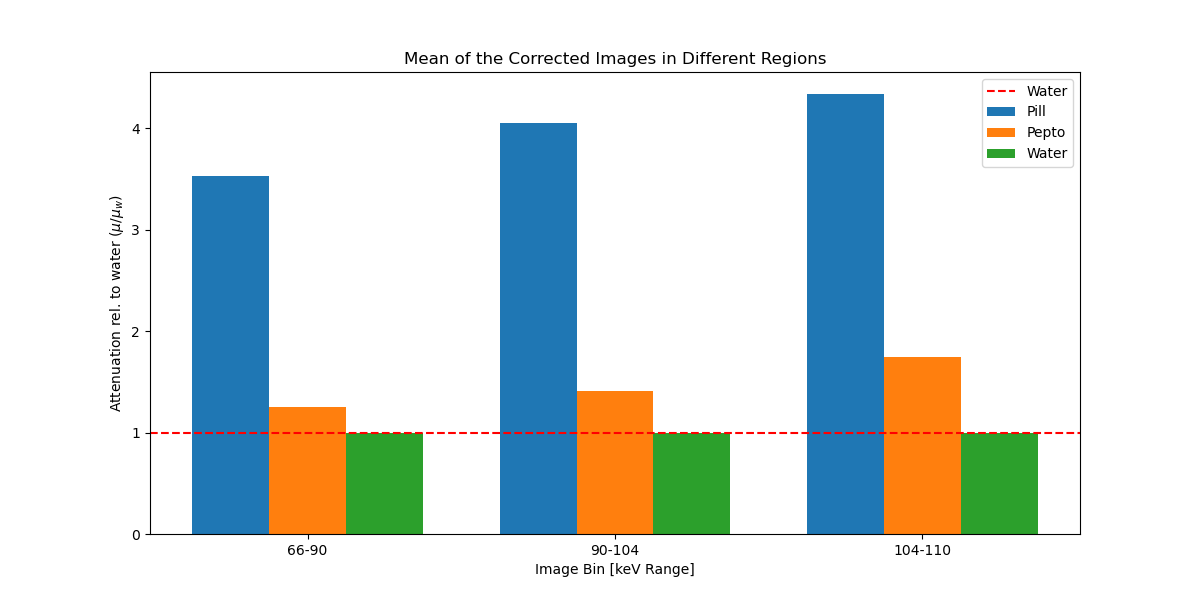

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming corrected_images and names are already defined
regions = [[25, 50], [75, 90], [120, 140]]
region_names = ['Pill', 'Pepto', 'Water']

# Calculate the mean values for the specified regions
values = []
for i in range(3):
    region_values = []
    for j in range(2, 5):
        mean_value = np.mean(corrected_images[j][regions[i][0]:regions[i][1], 10:-10])/ np.mean(corrected_images[j][regions[2][0]:regions[2][1], 10:-10])
        region_values.append(mean_value)
    values.append(region_values)

# Convert the values list to a numpy array for easier manipulation
values = np.array(values)

# Calculate the relative attenuation of Pill and Pepto to Water
relative_values = values[:, :2] / values[:, 2:]

# Create a bar chart for absolute values
x = np.arange(2, 5)  # There are 3 images in each region
width = 0.25  # Width of the bars

plt.figure(figsize=(12, 6))

for i in range(3):
    plt.bar(x + i*width, values[i], width, label=region_names[i])

plt.xlabel('Image Bin [keV Range]')
plt.ylabel('Attenuation rel. to water ($\mu/\mu_w$)')
plt.title('Mean of the Corrected Images in Different Regions')
plt.xticks(x + width, [f'{name}' for name in names[2:5]])
# plot a red dotted line at 1
plt.axhline(1, color='red', linestyle='--', label='Water')
plt.legend()
plt.show()